In [240]:
!pip3 install seaborn --break-system-packages
!pip3 install matplotlib --break-system-packages
!pip3 install scikit-learn --break-system-packages


  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [241]:

import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

titanic_dataframe = sns.load_dataset('titanic')

titanic_dataframe.head(10)



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [127]:
#print info
titanic_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
#stastical information
#print() is used so that both results show, a bare expression only
#displays the last one in the cell
print("Statistical summary")
print(titanic_dataframe.describe())

#shape of the dataframe
print("\nShape of the dataframe (rows, columns)")
print(titanic_dataframe.shape)


In [102]:
titanic_dataframe['fare'].sort_values(ascending=False).head(30)

258    512.3292
737    512.3292
679    512.3292
88     263.0000
27     263.0000
341    263.0000
438    263.0000
311    262.3750
742    262.3750
118    247.5208
299    247.5208
557    227.5250
700    227.5250
380    227.5250
716    227.5250
527    221.7792
377    211.5000
730    211.3375
779    211.3375
689    211.3375
318    164.8667
856    164.8667
268    153.4625
332    153.4625
609    153.4625
498    151.5500
305    151.5500
297    151.5500
708    151.5500
195    146.5208
Name: fare, dtype: float64

In [103]:
#percentage of null values in each colom
missing_values = titanic_dataframe.isnull().sum() / len(titanic_dataframe) * 100
print(f"Missing values in each colom \n\n{missing_values}")

Missing values in each colom 

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [104]:

#save the loaded DataFrame as a committed offline fallback
# saving the data to csv file from dataframe.
titanic_dataframe.to_csv("titanic.csv", index=False)

# 2 Apply missing-value handling

In [105]:
#iterate over the missing values result.
coloms_with_null_less_5 = []
for name, value in missing_values.items():
    if value <= 5 and value != 0:
        print(f"name {name} : value {value}")
        coloms_with_null_less_5.append(name)



name embarked : value 0.22446689113355783
name embark_town : value 0.22446689113355783


# Under 5% missing → drop those rows;

In [106]:
#under 5% missing → drop those rows;
# here embarked,embark_town two coloms are less then 5, so we need to drop off null rows.

print(coloms_with_null_less_5)
for null_coloum in coloms_with_null_less_5:
    titanic_dataframe.dropna(subset=[null_coloum], inplace=True)

#verify are there any null rows in embarked colom
titanic_dataframe[titanic_dataframe['embarked'].isna()]
#verify are there any null rows in embark_town colom
titanic_dataframe[titanic_dataframe['embark_town'].isna()]




['embarked', 'embark_town']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


# 5%–30% missing → impute

In [107]:
#iterate over the missing values result.
coloms_with_null_less_30 = []
for name, value in missing_values.items():
    if value > 5 and value <= 30:
        print(f"name {name} : value {value}")
        coloms_with_null_less_30.append(name)

coloms_with_null_less_30

name age : value 19.865319865319865


['age']

In [108]:
#imputing the missing values with median since it is numberic in the 'age' colom
titanic_dataframe['age'] = titanic_dataframe['age'].fillna(titanic_dataframe['age'].median())

In [109]:
#verifying the null values in the 'age' colom
titanic_dataframe[titanic_dataframe['age'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


# Reason for dropping the deck colom
## 1)more than 50% null values will create the noise in the data.
## 2)if we drop the 77% of data which is null, can be a huge data loss.
## 3)imputing the mojarity of the data with imaginative data is not correct which will misslead the model. 

In [155]:
titanic_dataframe = titanic_dataframe.drop(columns=['deck'])

In [156]:
titanic_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


# Justificatoin:

### The reason for dropping the null rows for embarked and embark_town coloms, since the volumne of null values 

### The reason for imputing the null values in the age colom is again volumn and data type is numaric. Along with that there is not much bias will be introduced when we are imputing the less than 20% data. 

### Reason for dropping the deck colom is majority of the row are null 77%. 

# 3 Univariate analysis: Plots:

### plot a histogram and a box plot for both age and fare

# Histogram plot for Age

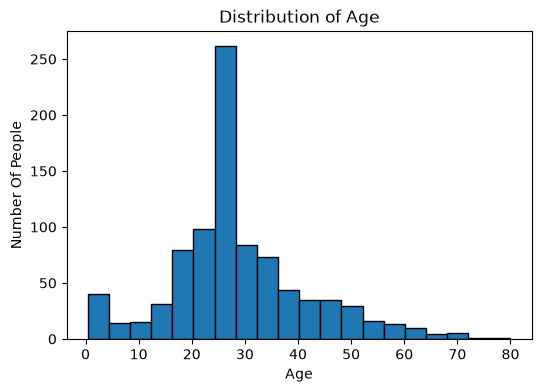

In [112]:
#histogram plot for age
import matplotlib.pyplot as plt

#below methos will deside the size of the diagram in the editor
plt.figure(figsize=(6,4))
#bins parameter will deside number of bars that are required to show 
#edgecolor will give the seperation between each bar.
plt.hist(titanic_dataframe['age'], bins=20, edgecolor='black')

#title for the diagram
plt.title('Distribution of Age')
#X - Axis represents the age of the passenger
plt.xlabel("Age")

#Y - Axis represents the number of people in that age group
plt.ylabel("Number Of People")

#displaying the graph on the console
plt.show()





# Box plot for Age

In [ ]:
#box plot for age, the dots beyond the whiskers are the IQR outliers
plt.figure(figsize=(6,4))

plt.boxplot(titanic_dataframe['age'].dropna(), vert=False)

plt.title('Box Plot of Age')
#X - Axis represents the age of the passenger
plt.xlabel("Age")

plt.show()

# Histogram plot for fare

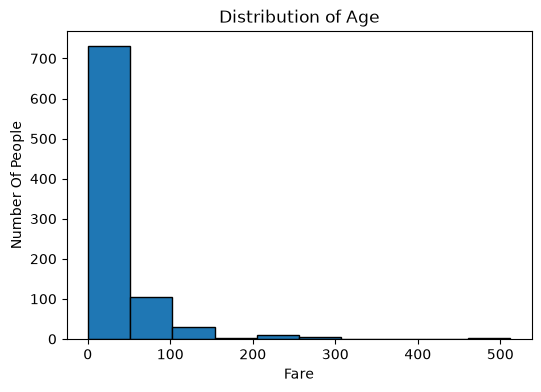

In [113]:
#histogram plot for age
import matplotlib.pyplot as plt

#below methos will deside the size of the diagram in the editor
plt.figure(figsize=(6,4))
#bins parameter will deside number of bars that are required to show 
#edgecolor will give the seperation between each bar.
plt.hist(titanic_dataframe['fare'], bins=10, edgecolor='black')

#title for the diagram
plt.title('Distribution of Age')
#X - Axis represents the fare of the ticket
plt.xlabel("Fare")

#Y - Axis represents the number of people in that with that fare
plt.ylabel("Number Of People")

#displaying the graph on the console
plt.show()

# Box plot for fare

In [ ]:
#box plot for fare, it shows the median, the quartiles and the outliers
plt.figure(figsize=(6,4))

plt.boxplot(titanic_dataframe['fare'].dropna(), vert=False)

plt.title('Box Plot of Fare')
#X - Axis represents the fare of the ticket
plt.xlabel("Fare")

plt.show()

# Using the IQR rule (outliers are points outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]), report how many outliers each column has. 

# Outliers can calculated for only numberic coloms

In [114]:
# formula for outliers
# Lower Bound=Q1−1.5×IQR
# Upper Bound=Q3+1.5×IQR

# Q1 = titanic_dataframe['colom_name'].quantile(0.25)
# Q3 = titanic_dataframe['colom_name'].quantile(0.75)
# IQR = Q3 - Q1

In [129]:
# get the numberic coloms

numberic_columns = titanic_dataframe.select_dtypes(include=['number']).columns

print(f"Numeric columns : {numberic_columns}")

Numeric columns : Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


In [ ]:
outlier_counts = {}

for numberic_column in numberic_columns:
    Q1 = titanic_dataframe[numberic_column].quantile(0.25)
    Q3 = titanic_dataframe[numberic_column].quantile(0.75)
    IQR = Q3 - Q1
    print(f"column name {numberic_column} and the IQR {IQR}")

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")

    #creating the dictionary with outliers
    outlier_counts[numberic_column] = ((titanic_dataframe[numberic_column] < lower_bound) 
    | (titanic_dataframe[numberic_column] > upper_bound)).sum()

#displaying the outliers count for all coloums
for column, count in outlier_counts.items():
    print(f"{column}: {count} outliers")


#### Age outliers before and after imputation


In [ ]:
import pandas as pd

#The counts above are measured on the cleaned frame, where the 177 missing ages
#have already been filled with the median. Filling adds a lot of values at the
#centre, which narrows the gap between Q1 and Q3 and therefore widens the number
#of points that fall outside the whiskers. Reporting the pre-imputation count as
#well, read back from the raw csv that was saved right after loading.
raw_age = pd.read_csv("titanic.csv")['age'].dropna()

Q1 = raw_age.quantile(0.25)
Q3 = raw_age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

raw_age_outliers = ((raw_age < lower_bound) | (raw_age > upper_bound)).sum()

print(f"age before imputation : IQR range [{Q1}, {Q3}] -> {raw_age_outliers} outliers")
print(f"age after imputation  : IQR range "
      f"[{titanic_dataframe['age'].quantile(0.25)}, {titanic_dataframe['age'].quantile(0.75)}]"
      f" -> {outlier_counts['age']} outliers")


# Compute mean, median, and mode for fare, and state in writing whether its distribution is right-skewed, left-skewed, or symmetric, referencing the mean/median/mode ordering.

In [149]:
fare_mean = titanic_dataframe['fare'].mean()
fare_median = titanic_dataframe['fare'].median()
fare_mode = titanic_dataframe['fare'].mode()[0]

print(f"fare_mean : {fare_mean:.2f} and fare_median : {fare_median:.2f} and fare_mode : {fare_mode:.2f}")

fare_mean : 32.20 and fare_median : 14.45 and fare_mode : 8.05


# Justification
 ## Mean = 32.20
 ## Median = 14.45
 ## Mode = 8.05

 #### Mean (32.20) > Median (14.45) > Mode (8.05)

 ##### This indicates the fare distribution is right-skewed(positively skewed).
 ##### Beacause the mean is pulled upward, since very small number of passengers paid very high aount to the ticket.

# 4 Bivariate analysis: using boolean masking (with &/| combinations), compute and report survival rate broken down by (a) sex

In [174]:
male_passengers = titanic_dataframe['sex'] == 'male'
survived_passengers = titanic_dataframe['survived'] == 1

male_survived_passengers  = male_passengers & survived_passengers


total_male_passengers = titanic_dataframe[male_passengers].shape[0]
print(f"Total Male passengers : {total_male_passengers}")


total_male_survivors = titanic_dataframe[male_survived_passengers].shape[0]
print(f"Total Male Survivors : {total_male_survivors}")

male_survival_rate = (total_male_survivors / total_male_passengers) * 100

print(f"Male survivel rate is : {male_survival_rate:.2f}")

Total Male passengers : 577
Total Male Survivors : 109
Male survivel rate is : 18.89


In [177]:
female_passengers = titanic_dataframe['sex'] == 'female'
survived_passengers = titanic_dataframe['survived'] == 1

female_survived_passengers  = female_passengers & survived_passengers


total_female_passengers = titanic_dataframe[female_passengers].shape[0]
print(f"Total Female passengers : {total_female_passengers}")


total_female_survivors = titanic_dataframe[female_survived_passengers].shape[0]
print(f"Total Female Survivors : {total_female_survivors}")

female_survival_rate = (total_female_survivors / total_female_passengers) * 100

print(f"Female survivel rate is : {female_survival_rate:.2f}")

Total Female passengers : 314
Total Female Survivors : 233
Female survivel rate is : 74.20


In [178]:
print(f"Male survivel rate is : {male_survival_rate:.2f}")
print(f"Female survivel rate is : {female_survival_rate:.2f}")

Male survivel rate is : 18.89
Female survivel rate is : 74.20


# (b) pclass

#### for pclass we have mutliple values, which we dont know.
#### get the unique values first
#### after the iterate over the unique classes for getting the survival rate

In [192]:
for unique_class in titanic_dataframe['pclass'].unique():
    #print(f"unique_class {unique_class}")
    total_pclass = titanic_dataframe['pclass'] == unique_class
    survived_passengers = titanic_dataframe['survived'] == 1
    survived_by_class = total_pclass & survived_passengers
    num_survived_by_class = titanic_dataframe[survived_by_class].shape[0]
    num_survived_passengers = titanic_dataframe[survived_passengers].shape[0]
    #print(f" num_survived_by_class : {num_survived_by_class} and num_survived_passengers {num_survived_passengers}")
    rate_survived_by_class = (num_survived_by_class / num_survived_passengers) * 100
    print(f"surival rate for class {unique_class}  is  : {rate_survived_by_class:.2f}")

surival rate for class 3  is  : 34.80
surival rate for class 1  is  : 39.77
surival rate for class 2  is  : 25.44


# (c) sex and pclass together. 

In [207]:

for sex in titanic_dataframe['sex'].unique():
    for unique_class in titanic_dataframe['pclass'].unique():
        #print(f"unique_class {unique_class}")
        total_pclass_sex = ((titanic_dataframe['pclass'] == unique_class) & (titanic_dataframe['sex'] == sex))
        #print(f"sex and class and total : {sex}, {unique_class}, {titanic_dataframe[total_pclass_sex].shape[0]}")
        survived_passengers = ((titanic_dataframe['survived'] == 1) & (titanic_dataframe['pclass'] == unique_class) & (titanic_dataframe['sex'] == sex))
        #print(f"sex and class and survived  : {sex}, {unique_class}, {titanic_dataframe[survived_passengers].shape[0]}")
        num_survived_by_class_sex = titanic_dataframe[survived_passengers].shape[0]
        num_survived_passengers = titanic_dataframe[total_pclass_sex].shape[0]
        #print(f" num_survived_by_class_sex : {num_survived_by_class_sex} and num_survived_passengers {num_survived_passengers}")
        rate_survived_by_class = (num_survived_by_class_sex / num_survived_passengers) * 100
        print(f"Sex : {sex.capitalize()}, Class : {unique_class}, Total : {titanic_dataframe[total_pclass_sex].shape[0]} and Survived : {num_survived_by_class_sex} ---> {sex.capitalize()} survival rate in {unique_class}  is  : {rate_survived_by_class:.2f}")


Sex : Male, Class : 3, Total : 347 and Survived : 47 ---> Male survival rate in 3  is  : 13.54
Sex : Male, Class : 1, Total : 122 and Survived : 45 ---> Male survival rate in 1  is  : 36.89
Sex : Male, Class : 2, Total : 108 and Survived : 17 ---> Male survival rate in 2  is  : 15.74
Sex : Female, Class : 3, Total : 144 and Survived : 72 ---> Female survival rate in 3  is  : 50.00
Sex : Female, Class : 1, Total : 94 and Survived : 91 ---> Female survival rate in 1  is  : 96.81
Sex : Female, Class : 2, Total : 76 and Survived : 70 ---> Female survival rate in 2  is  : 92.11


# Then compute a correlation matrix restricted to exactly these six columns: survived, pclass, age, sibsp, parch, and fare 

#### Use only the required six columns.

In [228]:
columns = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

correlation_matrix = titanic_dataframe[columns].corr()


# 5) Draw the Heatmap

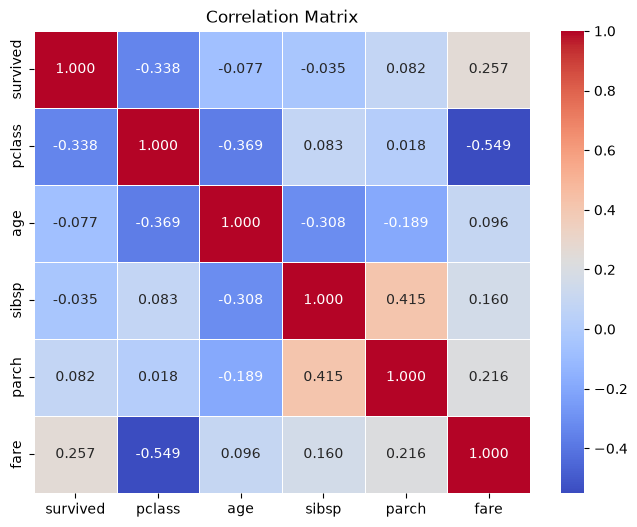

In [229]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.7
)

plt.title("Correlation Matrix")
plt.show()

#### Find the Two Strongest Correlations

In [231]:
corr = correlation_matrix.abs()

import numpy as np

corr = correlation_matrix.abs()

upper_triangle = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

#sorted pairs.
sorted_pairs = upper_triangle.stack().sort_values(ascending=False)

print(sorted_pairs.head(2))

pclass  fare     0.549500
sibsp   parch    0.414838
dtype: float64


#### 1) The strongest correlation is between Pclass and Fare, with a correlation coefficient of -0.5495. This tells us the negative correlation indicates that passengers traveling in higher classes generally paid higher fares, while passengers in lower classes typically paid lower fares.

#### 2) The second strongest correlation is between SibSp and Parch, with a correlation coefficient of 0.4148. This tells us the positive correlation suggests that passengers traveling with siblings or spouses were also more likely to travel with parents or children, reflecting that family members often traveled together.

#  Multivariate "data story": produce at least 4 distinct charts (any combination of bar/box/scatter/heatmap/pair-plot) that together build a coherent argument about who was more likely to survive and why. Each chart must be accompanied by a 2–4 sentence written interpretation in your README/notebook — a chart with no interpretation does not count.

##### Survival Rate by Sex (Bar Chart)

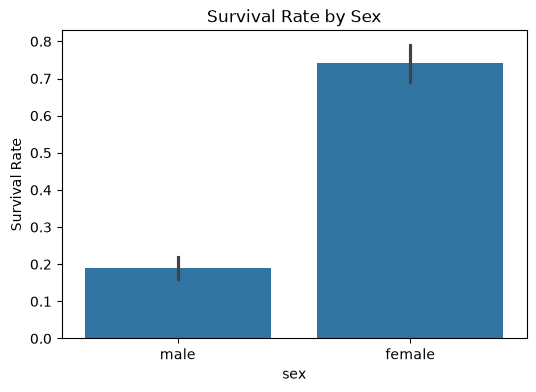

In [232]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=titanic_dataframe,
    x='sex',
    y='survived',
    estimator='mean'
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

##### Female passengers had a substantially higher survival rate than male passengers. This suggests that sex was one of the strongest factors associated with survival. Passenges who has travelled has given more preference to the females.

# 2) Survival Rate by Passenger Class

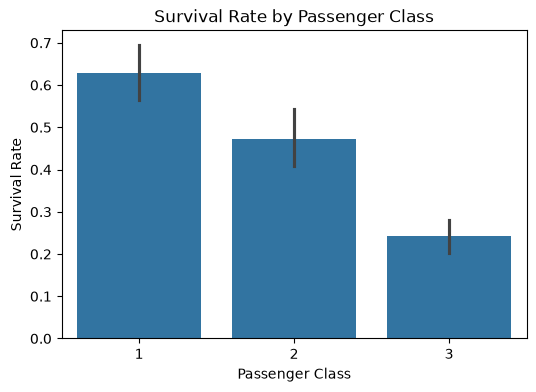

In [233]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=titanic_dataframe,
    x='pclass',
    y='survived',
    estimator='mean'
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

#### First-class passengers had the highest survival rate, while third-class passengers had the lowest. This indicates that social status and economic status and cabin location has influenced alot to access to lifeboats and evacuation path in the ship.

# 3) Age Distribution by Survival

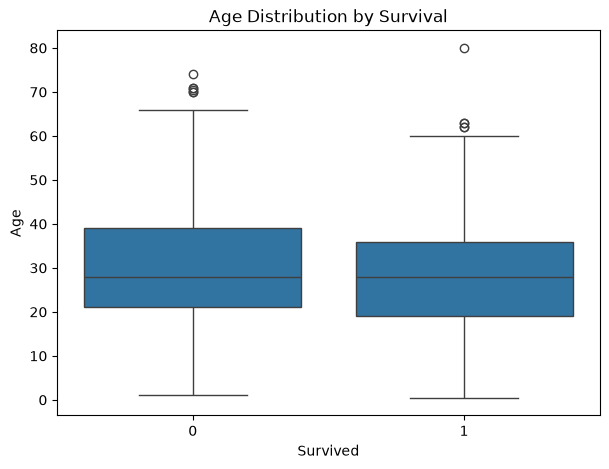

In [234]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=titanic_dataframe,
    x='survived',
    y='age'
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

#### The box plot shows the distribution of ages for survivors and non-survivors. While both groups span a wide range of ages, survivors tend to include more younger passengers, suggesting that children may have had a survival advantage.

# Fare vs Age Colored by Survival (Scatter Plot)

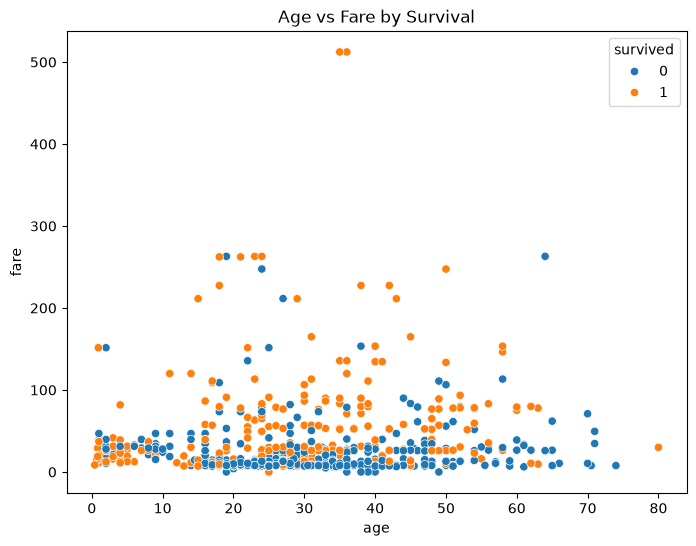

In [235]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=titanic_dataframe,
    x='age',
    y='fare',
    hue='survived'
)

plt.title("Age vs Fare by Survival")

plt.show()

#### Passengers who paid higher fares were more likely to survive, particularly among first-class travelers. Although age alone is not a strong predictor, fare combined with survival reveals that wealthier passengers generally had better survival outcomes.

# Correlation Heatmap

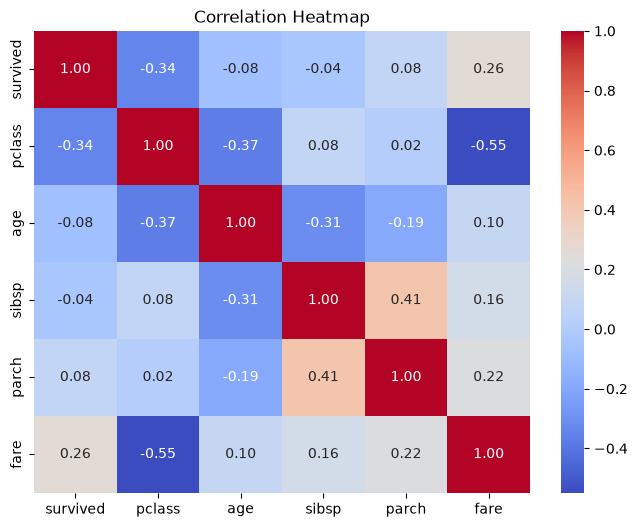

In [236]:
plt.figure(figsize=(8,6))

corr = titanic_dataframe[
    ['survived','pclass','age','sibsp','parch','fare']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#### The heatmap explains relationships among the numeric variables. The strongest correlation is between passenger class and fare, indicating that higher-class passengers generally paid higher fares. Passenger survival is mostly associated with both passenger class and fare, Hence the conclusion that class played an important role in survival.

# Survival by Sex and Passenger Class

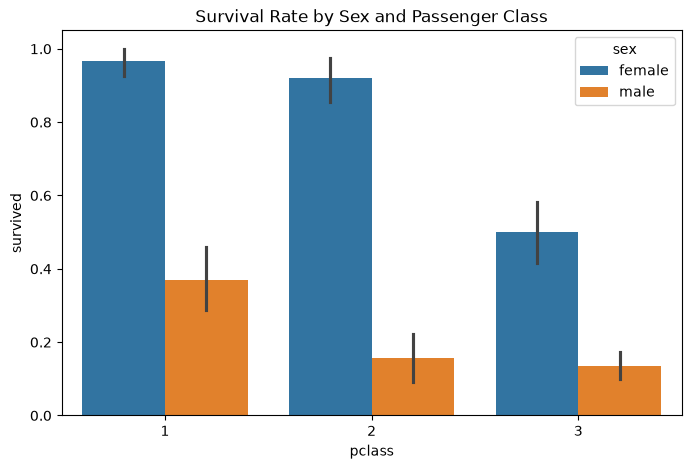

In [237]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=titanic_dataframe,
    x='pclass',
    y='survived',
    hue='sex',
    estimator='mean'
)

plt.title("Survival Rate by Sex and Passenger Class")

plt.show()

#### Female passengers had higher survival rates than males across all passenger classes. First-class females experienced the highest survival rates, while third-class males experienced the lowest. This demonstrates that both sex and passenger class jointly influenced survival, making them stronger predictors than either variable alone.

## Final conclusion

### The analysis indicates that survival on the Titanic was primarily influenced by sex and passenger class. Female passengers consistently had higher survival rates than males, supporting the historical "women and children first" evacuation policy. First-class passengers also survived at much higher rates than third-class passengers, suggesting that wealth and cabin location improved access to lifeboats. The scatter plot and correlation analysis further show that higher fares, which are associated with first-class travel, were linked to greater survival. Together, these visualizations demonstrate that survival was driven more by social and economic factors than by age alone.

#### work on the duplicate data with out modifying the cleaned data.

In [ ]:
scaler = StandardScaler()

eda_dataframe = titanic_dataframe.copy()
#Standardize age and fare
eda_dataframe[['age', 'fare']] = scaler.fit_transform(
    eda_dataframe[['age', 'fare']]
)

#Before scaling
print("Before Standardization")
print(titanic_dataframe[['age', 'fare']].agg(['mean', 'std']).round(3))

#After scaling, the mean should be about 0 and the standard deviation about 1
print("\nAfter Standardization")
print(eda_dataframe[['age', 'fare']].agg(['mean', 'std']).round(3))
